In [2]:
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker 
from xgboost import XGBClassifier
from sklearn.inspection import partial_dependence
import random
import os

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder
from sksurv.preprocessing import OneHotEncoder
from sklearn_pandas import DataFrameMapper

import torch
import torch.nn as nn
import torchtuples as tt

from torchtuples.callbacks import EarlyStopping
from sklearn.neural_network import MLPClassifier
from torch.utils.data import Dataset, DataLoader

In [3]:
# origianl dataset

In [4]:
df_train = pd.read_csv('df_train.csv')
df_test = pd.read_csv('df_test.csv') 

df_final = pd.concat([df_train, df_test], ignore_index=True)

In [5]:
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42)

In [6]:
# det dummy
dummy_f = ['REGION','MARST', 'RACEA', 'USBORN', 'HSTATYR', 'ALCSTAT1', 'SMOKESTATUS2']
df_train[dummy_f] = df_train[dummy_f].astype(int)
df_test[dummy_f] = df_test[dummy_f].astype(int)
df_val[dummy_f] = df_val[dummy_f].astype(int)
df_train = pd.get_dummies(df_train, columns=dummy_f, prefix=dummy_f)
df_val = pd.get_dummies(df_val, columns=dummy_f, prefix=dummy_f)
df_test = pd.get_dummies(df_test, columns=dummy_f, prefix=dummy_f)

In [7]:
# list of columns to standardize
cols_stand = ['AGE', 'BMICALC', 'HRSLEEP']
              
cols_norm = ['FAMSIZE', 'EDUCREC1', 'POVERTY', 'FSRAWSCORE', 'ALC5UPYR', 'ALCAMT', 'ALCDAYSYR',
              'CIGSDAY', 'MOD10DMIN', 'MOD10FWK', 'VIG10DMIN', 'VIG10FWK', 'STRONGFWK', 'AEFFORT', 
              'AFEELINT1MO', 'AWORTHLESS', 'WRYMEDCST', 'WRYRET',
              'SEX', 'HINOTCOVE', 'HIPRIVATEE', 'HIMCAIDE', 'HIMCAREE', 'ARTHGLUPEV',
              'BLIND', 'CANCEREV', 'CHEARTDIEV', 'CPOXEV', 'DIABETICEV', 'EMPHYSEMEV',
              'HEARTATTEV', 'HEARTCONEV', 'HYPERTENEV', 'KIDNEYWKYR', 'LIVERCHRON',
              'LIVERCONYR', 'STROKEV']

# list of columns not to standardize
cols_leave = [col for col in df_train.columns if col not in cols_stand + cols_norm + ['TIMETOEVENT', 'MORTSTAT']]

# Create mapper entries
standardize = [([col], StandardScaler()) for col in cols_stand]
normalize = [([col], MinMaxScaler()) for col in cols_norm]
leave = [(col, None) for col in cols_leave]

# Combine into one mapper
x_mapper = DataFrameMapper(standardize + normalize + leave, df_out=False)

In [8]:
# Transform with DataFrameMapper and convert to PyTorch tensors
x_train = torch.tensor(x_mapper.fit_transform(df_train.drop(columns=['MORTSTAT', 'TIMETOEVENT'])), dtype=torch.float32)

x_val = torch.tensor(x_mapper.transform(df_val.drop(columns=['MORTSTAT', 'TIMETOEVENT'])), dtype=torch.float32)

x_test = torch.tensor(x_mapper.transform(df_test.drop(columns=['MORTSTAT', 'TIMETOEVENT'])), dtype=torch.float32)

In [9]:
# define three-year mortality status as PyTorch tensors
y_train = torch.tensor(np.where((df_train["MORTSTAT"] == 1) & (df_train["TIMETOEVENT"] <= 3), 1, 0), dtype=torch.float32).view(-1, 1)

y_val = torch.tensor(np.where((df_val["MORTSTAT"] == 1) & (df_val["TIMETOEVENT"] <= 3), 1, 0), dtype=torch.float32).view(-1, 1)

y_test = torch.tensor(np.where((df_test["MORTSTAT"] == 1) & (df_test["TIMETOEVENT"] <= 3), 1, 0), dtype=torch.float32).view(-1, 1)

In [10]:
# set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) 
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)


# define the network
in_features = x_train.shape[1]
net = tt.practical.MLPVanilla(in_features, [32], 1, activation=nn.ReLU, dropout=0.5)


# model and optimizer 
loss_fn = nn.BCEWithLogitsLoss()
model = tt.Model(net, loss_fn, tt.optim.Adam)  
model.optimizer.set_lr(0.010)  


# training setup      batch size=800, epochs=60, lr=0.005, dropout=0.2, num nodes=[32]
batch_size = 800
epochs = 60
checkpoint_path = 'best_model.pt'
# early stopping
if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)
callbacks = [EarlyStopping(patience=20, file_path=checkpoint_path)]


# fit
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, val_data=(x_test, y_test), 
                shuffle=True, callbacks=callbacks, verbose=True)

0:	[0s / 0s],		train_loss: 0.2639,	val_loss: 0.1121
1:	[0s / 0s],		train_loss: 0.1224,	val_loss: 0.1103
2:	[0s / 0s],		train_loss: 0.1186,	val_loss: 0.1095
3:	[0s / 0s],		train_loss: 0.1169,	val_loss: 0.1088
4:	[0s / 0s],		train_loss: 0.1165,	val_loss: 0.1085
5:	[0s / 1s],		train_loss: 0.1163,	val_loss: 0.1087
6:	[0s / 1s],		train_loss: 0.1163,	val_loss: 0.1081
7:	[0s / 1s],		train_loss: 0.1149,	val_loss: 0.1083
8:	[0s / 1s],		train_loss: 0.1156,	val_loss: 0.1081
9:	[0s / 1s],		train_loss: 0.1154,	val_loss: 0.1078
10:	[0s / 1s],		train_loss: 0.1149,	val_loss: 0.1080
11:	[0s / 2s],		train_loss: 0.1154,	val_loss: 0.1080
12:	[0s / 2s],		train_loss: 0.1154,	val_loss: 0.1086
13:	[0s / 2s],		train_loss: 0.1149,	val_loss: 0.1079
14:	[0s / 2s],		train_loss: 0.1151,	val_loss: 0.1081
15:	[0s / 3s],		train_loss: 0.1146,	val_loss: 0.1082
16:	[0s / 3s],		train_loss: 0.1141,	val_loss: 0.1076
17:	[0s / 3s],		train_loss: 0.1148,	val_loss: 0.1082
18:	[0s / 3s],		train_loss: 0.1141,	val_loss: 0.1079
19:

In [11]:
# get adjusted dataset

In [12]:
# Load the saved x_vals and y_vals from the file
data = np.load('x_y_vals.npz')

# Extract x_vals and y_vals
x_vals = data['x_vals']
y_vals = data['y_vals']

# Define the interpolation function T
def T(x):
    return np.interp(x, x_vals, y_vals)

In [13]:
df_train_1990 = df_train.copy()
df_val_1990 = df_val.copy()
df_test_1990 = df_test.copy()
df_final_1990 = df_final.copy()

df_train_1990['BMICALC'] = T(df_train_1990['BMICALC'].values)
df_val_1990['BMICALC'] = T(df_val_1990['BMICALC'].values)
df_test_1990['BMICALC'] = T(df_test_1990['BMICALC'].values)
df_final_1990['BMICALC'] = T(df_final_1990['BMICALC'].values)

In [14]:
# Transform with DataFrameMapper and convert to PyTorch tensors
x_train_1990 = torch.tensor(x_mapper.transform(df_train_1990.drop(columns=['MORTSTAT', 'TIMETOEVENT'])), dtype=torch.float32)
x_test_1990 = torch.tensor(x_mapper.transform(df_test_1990.drop(columns=['MORTSTAT', 'TIMETOEVENT'])), dtype=torch.float32)
x_val_1990 = torch.tensor(x_mapper.transform(df_val_1990.drop(columns=['MORTSTAT', 'TIMETOEVENT'])), dtype=torch.float32)

# define three-year mortality status as PyTorch tensors
y_train_1990 = torch.tensor(np.where((df_train_1990["MORTSTAT"] == 1) & (df_train_1990["TIMETOEVENT"] <= 3), 1, 0), dtype=torch.float32).view(-1, 1)
y_test_1990 = torch.tensor(np.where((df_test_1990["MORTSTAT"] == 1) & (df_test_1990["TIMETOEVENT"] <= 3), 1, 0), dtype=torch.float32).view(-1, 1)
y_val_1990 = torch.tensor(np.where((df_val_1990["MORTSTAT"] == 1) & (df_val_1990["TIMETOEVENT"] <= 3), 1, 0), dtype=torch.float32).view(-1, 1)

In [15]:
# --- get predictions ---

In [16]:
probs_train = torch.sigmoid(model.predict(x_train))
probs_val = torch.sigmoid(model.predict(x_val))
probs_test = torch.sigmoid(model.predict(x_test))
probs_train = torch.cat((probs_train, probs_val), dim=0)
probs_final = torch.cat((probs_train, probs_test), dim=0)

probs_train_1990 = torch.sigmoid(model.predict(x_train_1990))
probs_val_1990 = torch.sigmoid(model.predict(x_val_1990))
probs_test_1990 = torch.sigmoid(model.predict(x_test_1990))
probs_train_1990 = torch.cat((probs_train_1990, probs_val_1990), dim=0)
probs_final_1990 = torch.cat((probs_train_1990, probs_test_1990), dim=0)

In [17]:
probs_train = probs_train.flatten().tolist()
probs_test = probs_test.flatten().tolist()
probs_final = probs_final.flatten().tolist()
probs_test_1990 = probs_test_1990.flatten().tolist()
probs_train_1990 = probs_train_1990.flatten().tolist()
probs_final_1990 = probs_final_1990.flatten().tolist()

probs_final_1990 = np.array(probs_final_1990)
probs_final = np.array(probs_final)
probs_train_1990 = np.array(probs_train_1990)
probs_train = np.array(probs_train)
probs_test_1990 = np.array(probs_test_1990)
probs_test = np.array(probs_test)

In [18]:
# --- MSD ---
print(f"final dataset {np.mean((probs_final_1990 - probs_final) ** 2):.6f}")
print(f"training dataset {np.mean((probs_train_1990 - probs_train) ** 2):.6f}")
print(f"test dataset {np.mean((probs_test_1990 - probs_test) ** 2):.6f}")

final dataset 0.000050
training dataset 0.000050
test dataset 0.000052


In [19]:
# --- MAD ---
print(f"final dataset {np.mean(np.abs(probs_final_1990 - probs_final)):.5f}")
print(f"training dataset {np.mean(np.abs(probs_train_1990 - probs_train)):.5f}")
print(f"test dataset {np.mean(np.abs(probs_test_1990 - probs_test)):.5f}")

final dataset 0.00223
training dataset 0.00224
test dataset 0.00223


In [20]:
# --- SGR ---
indicator_final = np.array([1 if p > p_adj else 0 for p, p_adj in zip(probs_final, probs_final_1990)])
print(f"final dataset {np.mean(indicator_final)}")
indicator_train = np.array([1 if p > p_adj else 0 for p, p_adj in zip(probs_train, probs_train_1990)])
print(f"train dataset {np.mean(indicator_train)}")
indicator_test = np.array([1 if p > p_adj else 0 for p, p_adj in zip(probs_test, probs_test_1990)])
print(f"test dataset {np.mean(indicator_test)}")

final dataset 0.6202224371373307
train dataset 0.6210348162475822
test dataset 0.6169729206963249


In [21]:
# --- SGR ---
indicator_final = np.array([1 if p < p_adj else 0 for p, p_adj in zip(probs_final, probs_final_1990)])
print(f"final dataset {np.mean(indicator_final)}")
indicator_train = np.array([1 if p < p_adj else 0 for p, p_adj in zip(probs_train, probs_train_1990)])
print(f"train dataset {np.mean(indicator_train)}")
indicator_test = np.array([1 if p < p_adj else 0 for p, p_adj in zip(probs_test, probs_test_1990)])
print(f"test dataset {np.mean(indicator_test)}")

final dataset 0.3797678916827853
train dataset 0.37895309477756284
test dataset 0.383027079303675


In [22]:
# --- plot ---

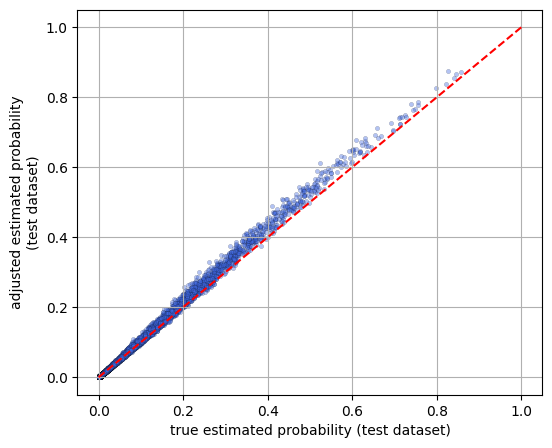

In [23]:
plt.figure(figsize=(6,5))
plt.scatter(probs_test, probs_test_1990, color='royalblue', edgecolor='black', linewidths=0.2, s=10, alpha=0.4)   
plt.xlabel(f'true estimated probability (test dataset)')
plt.ylabel(f'adjusted estimated probability\n(test dataset)')
plt.grid(True)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.savefig('simple_DSC_diagnoal_test.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

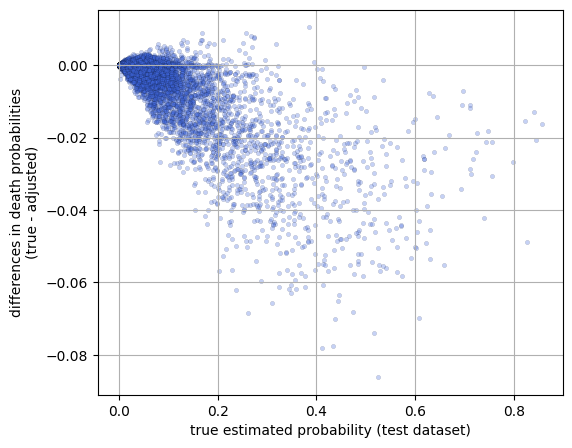

In [27]:
plt.figure(figsize=(6,5))
plt.scatter(probs_test, probs_test - probs_test_1990, color='royalblue', edgecolor='black', linewidths=0.2, s=10, alpha=0.3)  
plt.xlabel('true estimated probability (test dataset)')
plt.ylabel(f'differences in death probabilities\n(true - adjusted)')
plt.grid(True)
plt.savefig('simple_DSC_prob_differences_test.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

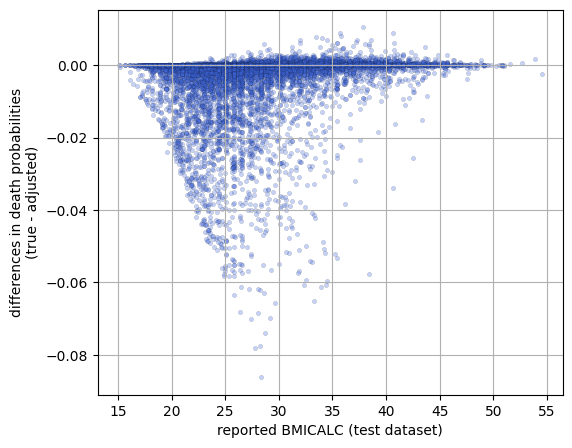

In [26]:
plt.figure(figsize=(6,5))
plt.scatter(df_test['BMICALC'], probs_test- probs_test_1990, color='royalblue', edgecolor='black', linewidths=0.2, s=10, alpha=0.3)  
plt.xlabel('reported BMICALC (test dataset)')
plt.ylabel(f'differences in death probabilities\n(true - adjusted)')
plt.grid(True)
plt.savefig('simple_DSC_bmi_test.png', format='png', dpi=300, bbox_inches='tight')
plt.show()